In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt


x shape: torch.Size([1, 16, 10, 20])
tensor([[[-1.0429,  0.1745, -0.8236, -0.0617,  0.7901, -0.0164, -0.4394,
          -0.4883,  1.7932,  0.3134,  1.1929,  0.9871, -0.5655, -0.9742,
           0.2264, -0.5897, -0.8651,  0.8846,  1.0703,  1.0975],
         [-0.8926,  0.0228, -0.6154,  1.2144,  0.2965, -0.8300, -0.0577,
          -0.3035,  1.2197,  0.6879, -0.2572, -0.4824,  0.6616,  0.4752,
          -0.8036, -0.5607, -0.3708,  1.1412, -0.8356, -0.3693],
         [ 0.7529,  0.0441,  0.0208, -1.1422, -0.2251,  2.2182,  0.1826,
           0.0433,  2.1941, -0.2014, -1.2881,  0.2582,  0.5489,  0.8744,
          -0.6094,  0.5163, -0.7976,  1.1786,  0.0913, -1.2027],
         [ 0.6351, -0.1994,  0.0510,  1.1073, -1.9611, -0.4141, -1.3608,
           0.5670, -0.2112,  1.4236, -0.3187, -0.8407, -0.6976,  0.0718,
          -1.4510,  1.5808, -0.2180,  1.8800, -0.5386,  0.4852],
         [ 0.6173,  0.6804,  0.0667, -1.4811, -0.1627,  0.3717,  0.0315,
          -0.6546,  0.5250,  0.5726,  0.1501, 

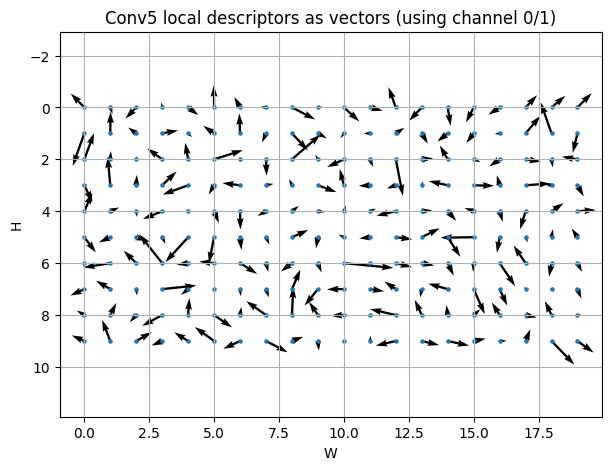

In [46]:


# 1) random tensor로 "Conv5 출력 형태" 만들기
# 입력 480x640에서 VGG16 conv5 (마지막 pool 제거)면 보통 H,W = 30,40
N, C, H, W = 1, 16, 10, 20
x = torch.randn(N, C, H, W)  # conv5 feature map 형태

print("x shape:", x.shape)   # (1, 512, 30, 40)

# 2) 좌표평면에 descriptor 위치 + 벡터(quiver)로 표현
# 512차원 벡터를 그대로 화살표로 못 그리니, 시각화용으로 2채널만 사용(예: 0,1 채널)
feat2 = x[0, [0, 1], :, :]   # (2, H, W)
print(feat2)

Xg, Yg = np.meshgrid(np.arange(W), np.arange(H))  # 좌표 (w,h)
U = feat2[0].numpy()  # channel 0
V = feat2[1].numpy()  # channel 1

plt.figure(figsize=(7,5))
plt.quiver(Xg, Yg, U, V, angles='xy', scale_units='xy', scale=2)
plt.scatter(Xg, Yg, s=5)   # descriptor 위치
plt.gca().invert_yaxis()
plt.axis('equal')
plt.grid(True)
plt.title("Conv5 local descriptors as vectors (using channel 0/1)")
plt.xlabel("W")
plt.ylabel("H")
plt.show()

In [47]:
from sklearn.cluster import KMeans

K = 16  # num_clusters

# (N, C, H, W) -> (H*W, C)
X = x[0].permute(1, 2, 0).reshape(-1, C).numpy()
# X.shape = (H*W, C)

kmeans = KMeans(n_clusters=K, random_state=0, n_init=10)
labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

print("X shape:", X.shape)            # (H*W, C)
print("labels shape:", labels.shape)  # (H*W,)
print("centroids shape:", centroids.shape)  # (64, C)

X shape: (200, 16)
labels shape: (200,)
centroids shape: (16, 16)


[[-1.0428576  -1.0741019 ]
 [ 0.17446993  0.5073783 ]
 [-0.8235652   0.867364  ]
 [-0.06171205 -0.38594848]
 [ 0.7900802   0.59023076]
 [-0.01638641 -1.7089397 ]
 [-0.43944424 -0.80147666]
 [-0.4882853  -0.01076382]
 [ 1.7932498   0.9263099 ]
 [ 0.31336683 -0.05740037]
 [ 1.1928982   1.0738162 ]
 [ 0.9871331   0.25994393]
 [-0.5655365  -1.5587775 ]
 [-0.9741608   1.0349094 ]
 [ 0.22640945  1.4174373 ]
 [-0.58974546  1.1508902 ]
 [-0.8650633   0.559208  ]
 [ 0.8846064  -0.93550634]
 [ 1.0702918  -0.89820427]
 [ 1.0975173  -1.1040869 ]
 [-0.89259714  2.507806  ]
 [ 0.02282916 -1.6714439 ]
 [-0.6154168  -0.45066202]
 [ 1.2144288  -0.22004505]
 [ 0.29647747  0.28754604]
 [-0.8300392  -0.5773809 ]
 [-0.0576741  -1.5394639 ]
 [-0.30346832  0.698175  ]
 [ 1.219727    1.3049419 ]
 [ 0.6879318   0.37461457]
 [-0.25724778  0.36665964]
 [-0.48242804  0.00761963]
 [ 0.6616185  -0.43280602]
 [ 0.4752198   0.7908171 ]
 [-0.80360055  0.6332012 ]
 [-0.5606788   0.7446431 ]
 [-0.37077555  0.05222452]
 

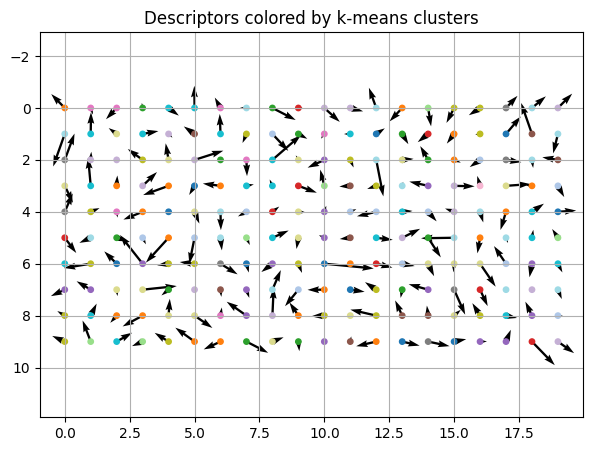

In [48]:
# labels: (H*W,), centroids: (64, C)

# 시각화용 2D 좌표(채널 0,1)만 사용
pts2 = X[:, :2]                 # (H*W, 2)
c2  = centroids[:, :2]          # (64, 2)

print(pts2)
plt.figure(figsize=(7,5))

# 기존 화살표
plt.quiver(Xg, Yg, U, V, angles='xy', scale_units='xy', scale=2)

# 클러스터별 점 (색으로 구분)
plt.scatter(Xg.ravel(), Yg.ravel(),
            c=labels, cmap='tab20', s=15, label='descriptors')

# centroid 표시 (좌표평면 원점 기준 벡터가 아니라, 분포 요약이므로 점으로)
plt.scatter(
    np.zeros(len(c2)), np.zeros(len(c2)), s=0  # 더미 (범례용)
)
# centroid를 벡터공간에 찍고 싶으면 아래처럼 별도 플롯 권장

plt.gca().invert_yaxis()
plt.axis('equal')
plt.grid(True)
plt.title("Descriptors colored by k-means clusters")
plt.show()

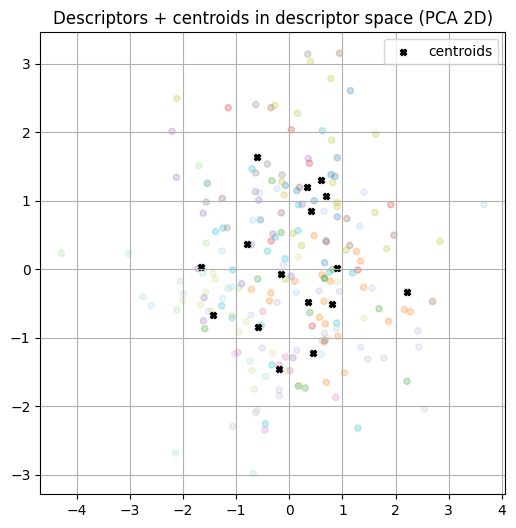

In [49]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# X: (H*W, C), centroids: (K, C)
Z = np.vstack([X, centroids])          # (H*W + K, C)
pca = PCA(n_components=2, random_state=0)
Z2 = pca.fit_transform(Z)

X2 = Z2[:X.shape[0]]                   # descriptors in 2D
C2 = Z2[X.shape[0]:]                   # centroids in 2D

plt.figure(figsize=(6,6))
plt.scatter(X2[:,0], X2[:,1], c=labels, s=20, alpha=0.25, cmap='tab20')
plt.scatter(C2[:,0], C2[:,1], s=20, marker='X', c='black', label='centroids')
plt.title("Descriptors + centroids in descriptor space (PCA 2D)")
plt.grid(True)
plt.legend()
plt.show()

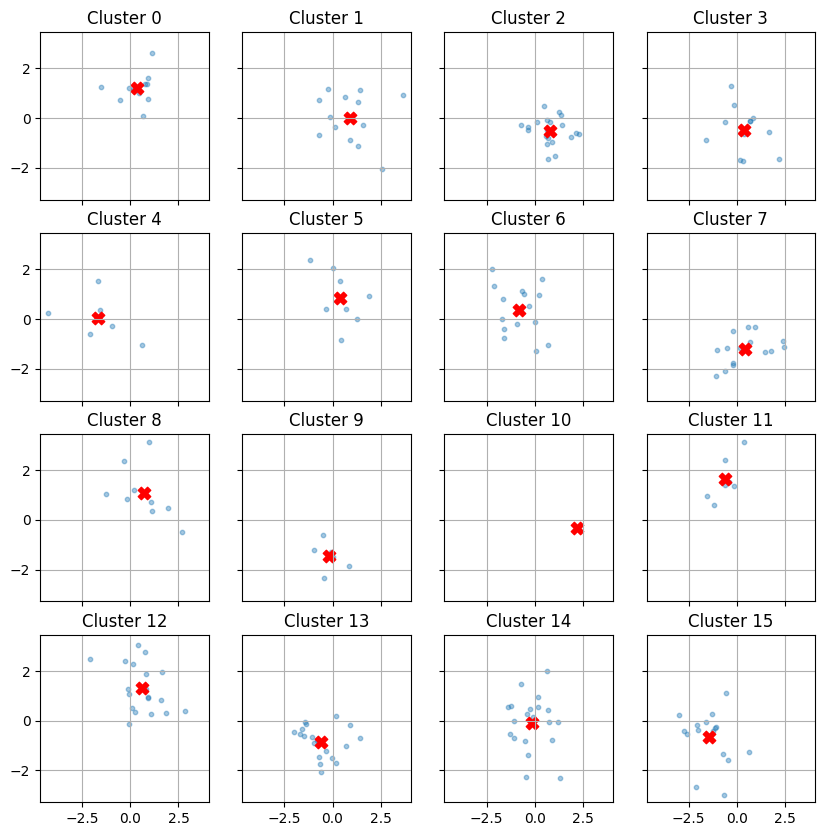

In [51]:
K = 16
cols = 4
rows = 4

fig, axes = plt.subplots(rows, cols, figsize=(10, 10), sharex=True, sharey=True)

for k in range(K):
    ax = axes[k // cols, k % cols]

    idx = (labels == k)

    # 해당 cluster의 descriptor
    ax.scatter(X2[idx, 0], X2[idx, 1],
               s=10, alpha=0.4)

    # centroid
    ax.scatter(C2[k, 0], C2[k, 1],
               s=80, marker='X', c='red')

    ax.set_title(f'Cluster {k}')
    ax.grid(True)

#plt.suptitle("PCA descriptor space – per cluster", y=1.02)
#plt.tight_layout()
plt.show()


In [66]:
import torch.nn.functional as F

vlad = torch.rand(3, 4)
print(vlad)
print(vlad.norm())
print(vlad.mean())
print(F.normalize(vlad))
print(vlad.view(2,-1))

print(pts2.shape)
print(c2.shape)


tensor([[0.0902, 0.9326, 0.1453, 0.9287],
        [0.0145, 0.5216, 0.5180, 0.2086],
        [0.1988, 0.1690, 0.8137, 0.1236]])
tensor(1.7581)
tensor(0.3887)
tensor([[0.0680, 0.7027, 0.1095, 0.6997],
        [0.0189, 0.6824, 0.6778, 0.2729],
        [0.2303, 0.1957, 0.9424, 0.1432]])
tensor([[0.0902, 0.9326, 0.1453, 0.9287, 0.0145, 0.5216],
        [0.5180, 0.2086, 0.1988, 0.1690, 0.8137, 0.1236]])
(200, 2)
(16, 2)
